# Native Infiltration Base and Region Override Authoring

This notebook uses HEC-RAS's native `RasMapperLib` to create the
geometry infiltration schema, edit the geometry-wide Base Overrides,
assign a distinct parameter table to one named region, recompute final
2D arrays, and run a complete gridded-precipitation simulation.

No HDF schema is hand-authored. Acceptance requires fresh native
readback, durable backups, spatial attribution in recomputed and final
plan-HDF arrays, cumulative infiltration output, and a measurable
hydraulic response.


## Native-first workflow contract

HEC-RAS has two separate geometry-override surfaces:

| Surface | HDF location | Canonical API | Meaning |
|---|---|---|---|
| Base Overrides | `/Geometry/Infiltration/Base Overrides` | `set_infiltration_base_overrides()` | Geometry-wide class-to-parameter fallback |
| Named region table | `/Geometry/Infiltration/Variables/*` | `set_infiltration_region_overrides()` | Parameters applied only while rasterizing that polygon |

A copied region polygon does **not** constrain Base Overrides. This
notebook deliberately assigns different values to the two surfaces and
proves their spatial effect in final solver-owned arrays.

Existing compatibility names remain working and time-bounded:

| Compatibility name | Replacement | Behavior/window |
|---|---|---|
| `create_infiltration_group()` | `create_infiltration_override_regions()` | Native wrapper through v1.1.x; removal no earlier than v1.2.0 |
| `set_infiltration_baseoverrides()` | `set_infiltration_base_overrides()` | Geometry-wide native wrapper through v1.1.x; removal no earlier than v1.2.0 |
| `scale_infiltration_baseoverrides()` | `scale_infiltration_base_overrides()` | Geometry-wide native wrapper through v1.1.x; removal no earlier than v1.2.0 |
| `set_infiltration_layer_data()` | `set_infiltration_sidecar_parameters()` | Native sidecar wrapper through v1.1.x; removal no earlier than v1.2.0 |
| `scale_infiltration_data()` | `scale_infiltration_base_overrides()`, `scale_infiltration_region_overrides()`, or `scale_infiltration_sidecar_parameters()` | Ambiguous name fails closed through v1.1.x; removal no earlier than v1.2.0 |

Regional get/set/scale methods are additive canonical APIs. They do not
deprecate the geometry-wide Base Override family. Stable read-only
APIs—including `get_infiltration_baseoverrides()` and the bulk
`get_infiltration_calibration_regions()` view—are retained.


In [1]:
from pathlib import Path
import sys
import logging

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (
        (candidate / "ras_commander" / "__init__.py").exists()
        and (candidate / "examples").exists()
    ):
        REPO_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate the ras-commander checkout")
repo_root_string = str(REPO_ROOT)
if repo_root_string in sys.path:
    sys.path.remove(repo_root_string)
sys.path.insert(0, repo_root_string)

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython.display import display

from ras_commander import RasCmdr, RasExamples, RasMap, init_ras_project
from ras_commander.hdf import (
    HdfInfiltration,
    HdfMesh,
    HdfResultsMesh,
)

logging.getLogger("ras_commander").setLevel(logging.WARNING)
for logger_name in list(logging.root.manager.loggerDict):
    if logger_name.startswith("ras_commander"):
        logging.getLogger(logger_name).setLevel(logging.WARNING)

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 180,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
    }
)

RAS_VERSION = "7.0"
PLAN_NUMBER = "06"
GEOMETRY_NUMBER = "09"
MESH_NAME = "BaldEagleCr"
REGION_NAME = "Main Channel"
BASE_SIGNAL_VALUES = {
    "Curve Number": 65.0,
    "Abstraction Ratio": 0.20,
    "Minimum Infiltration Rate": 0.10,
}
REGION_SIGNAL_VALUES = {
    "Curve Number": 55.0,
    "Abstraction Ratio": 0.15,
    "Minimum Infiltration Rate": 0.05,
}
assert all(
    BASE_SIGNAL_VALUES[name] != REGION_SIGNAL_VALUES[name]
    for name in BASE_SIGNAL_VALUES
)

WORK_ROOT = REPO_ROOT / "working" / "notebook_runs" / "CLB-903" / "218"
WORK_ROOT.mkdir(parents=True, exist_ok=True)


## Project and meteorologic context

Plan 06 uses geometry 09 and a five-day gridded-precipitation event over
the Bald Eagle Creek 2D mesh. Independent baseline and modified project
copies make the final-array and hydraulic comparisons reproducible.


In [2]:
RasExamples.get_example_projects(RAS_VERSION)
baseline_path = Path(
    RasExamples.extract_project(
        "BaldEagleCrkMulti2D",
        output_path=WORK_ROOT,
        suffix="218_baseline",
    )
)
modified_path = Path(
    RasExamples.extract_project(
        "BaldEagleCrkMulti2D",
        output_path=WORK_ROOT,
        suffix="218_modified",
    )
)
baseline_ras = init_ras_project(
    baseline_path,
    RAS_VERSION,
    ras_object="new",
    accept_tcu=True,
)
modified_ras = init_ras_project(
    modified_path,
    RAS_VERSION,
    ras_object="new",
    accept_tcu=True,
)

baseline_plan = baseline_ras.plan_df.loc[
    baseline_ras.plan_df["plan_number"] == PLAN_NUMBER
].iloc[0]
modified_geom = modified_ras.geom_df.loc[
    modified_ras.geom_df["geom_number"] == GEOMETRY_NUMBER
].iloc[0]
baseline_plan_hdf = (
    baseline_path / f"{baseline_ras.project_name}.p{PLAN_NUMBER}.hdf"
)
modified_plan_hdf = (
    modified_path / f"{modified_ras.project_name}.p{PLAN_NUMBER}.hdf"
)
modified_geometry_hdf = Path(modified_geom["hdf_path"])

flow_number = str(baseline_plan["unsteady_number"]).zfill(2)
flow_row = baseline_ras.unsteady_df.loc[
    baseline_ras.unsteady_df["unsteady_number"] == flow_number
].iloc[0]
context = pd.DataFrame(
    [
        {"item": "HEC-RAS runtime", "value": RAS_VERSION},
        {"item": "plan", "value": f"p{PLAN_NUMBER}: {baseline_plan['Plan Title']}"},
        {"item": "geometry", "value": f"g{GEOMETRY_NUMBER}"},
        {"item": "2D flow area", "value": MESH_NAME},
        {"item": "simulation period", "value": baseline_plan["Simulation Date"]},
        {"item": "computation interval", "value": baseline_plan["Computation Interval"]},
        {"item": "mapping interval", "value": baseline_plan["Mapping Interval"]},
        {"item": "precipitation mode", "value": flow_row["Precipitation Mode"]},
        {"item": "gridded precipitation source", "value": flow_row["Met BC=Precipitation|Gridded Source"]},
    ]
)
display(context)


,item,value
0,HEC-RAS runtime,7.0
1,plan,p06: Gridded Precip - Infiltration
2,geometry,g09
3,2D flow area,BaldEagleCr
4,simulation period,"09SEP2018,0000,14SEP2018,0000"
5,computation interval,20SEC
6,mapping interval,10MIN
7,precipitation mode,Enable
8,gridded precipitation source,DSS


## Baseline gridded-precipitation solve

The required-dataset contract includes all three final infiltration
arrays and cell cumulative infiltration depth. A completed process that
omits any requested output fails this gate.


In [3]:
infiltration_root = f"Geometry/2D Flow Areas/{MESH_NAME}/Infiltration"
timeseries_root = (
    "Results/Unsteady/Output/Output Blocks/Base Output/"
    f"Unsteady Time Series/2D Flow Areas/{MESH_NAME}"
)
infiltration_array_paths = {
    "Curve Number": f"{infiltration_root}/Curve Number",
    "Abstraction Ratio": f"{infiltration_root}/Abstraction Ratio",
    "Minimum Infiltration Rate": (
        f"{infiltration_root}/Minimum Infiltration Rate"
    ),
}
baseline_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=baseline_ras,
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert baseline_result.success, "Baseline HEC-RAS computation failed."
assert baseline_result.completion_verified is True

def read_infiltration_tables(path):
    tables = {}
    for name in infiltration_array_paths:
        table = HdfInfiltration.get_preprocessed_infiltration(
            path,
            mesh_name=MESH_NAME,
            variable=name,
        ).sort_values("cell_id")
        assert not table.empty, f"Missing final {name} values"
        assert table["cell_id"].is_unique
        tables[name] = table[["cell_id", "value"]].reset_index(drop=True)
    return tables

baseline_arrays = read_infiltration_tables(baseline_plan_hdf)
baseline_cumulative = HdfResultsMesh.get_mesh_timeseries(
    baseline_plan_hdf,
    MESH_NAME,
    "Cell Cumulative Infiltration Depth",
    truncate=False,
)
baseline_wse = HdfResultsMesh.get_mesh_max_ws(baseline_plan_hdf)
display(
    pd.DataFrame(
        [
            {
                "array": name,
                "active rows": len(table),
                "minimum": float(table["value"].min()),
                "maximum": float(table["value"].max()),
            }
            for name, table in baseline_arrays.items()
        ]
    )
)


,array,active rows,minimum,maximum
0,Curve Number,18066,36.0,100.00
1,Abstraction Ratio,18066,0.0,0.20
2,Minimum Infiltration Rate,18066,0.0,0.12


## Create the native geometry infiltration schema

HEC-RAS copies the geometry's existing native Land Cover (Manning's n)
region polygon and authors the complete infiltration schema. Creation
materializes both the geometry-wide Base Overrides table and a separate
parameter table for `Main Channel`; the polygon is a native region, not
a mask for the Base Overrides.


In [4]:
assert HdfInfiltration.get_infiltration_region_names(
    modified_geometry_hdf
) in (None, [])

created = HdfInfiltration.create_infiltration_override_regions(
    modified_geometry_hdf,
    region_names=[REGION_NAME],
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
create_backup = Path(created.attrs["backup_path"])
assert create_backup.exists()
assert created.attrs["recompute_required"] is True
assert len(created) == 136

region_names = HdfInfiltration.get_infiltration_region_names(
    modified_geometry_hdf
)
region_polygons = HdfInfiltration.get_infiltration_region_polygons(
    modified_geometry_hdf
)
initial_region_table = HdfInfiltration.get_infiltration_region_overrides(
    modified_geometry_hdf,
    region_name=REGION_NAME,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
assert region_names == [REGION_NAME]
assert len(region_polygons) == 1
assert not region_polygons.geometry.iloc[0].interiors
assert len(initial_region_table) == 136
original_region_polygon = region_polygons.geometry.iloc[0]
display(region_polygons)
display(created.head(8))


,region_id,Name,geometry
0,0,Main Channel,"POLYGON ((2007492.809 321808.759, 2007554.909 ..."


,Land Cover Name,Curve Number,Abstraction Ratio,Minimum Infiltration Rate
0,NoData,-9999.0,-9999.0,-9999.0
1,NoData : B,-9999.0,-9999.0,-9999.0
2,NoData : A,-9999.0,-9999.0,-9999.0
3,NoData : B-D,-9999.0,-9999.0,-9999.0
4,NoData : D,-9999.0,-9999.0,-9999.0
5,NoData : C,-9999.0,-9999.0,-9999.0
6,NoData : C-D,-9999.0,-9999.0,-9999.0
7,NoData : A-D,-9999.0,-9999.0,-9999.0


## Set geometry-wide Base Overrides

Every native class row receives a recognizable, valid base signal.
These are qualification values for a disposable model—not calibration
recommendations. The signal must later appear on all active cells that
are disjoint from the named region.


In [5]:
base_requested = created.copy()
for parameter, value in BASE_SIGNAL_VALUES.items():
    base_requested[parameter] = value

base_written = HdfInfiltration.set_infiltration_base_overrides(
    modified_geometry_hdf,
    base_requested,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
base_backup = Path(base_written.attrs["backup_path"])
assert base_backup.exists()
assert base_backup != create_backup
assert base_written.attrs["recompute_required"] is True
for parameter, value in BASE_SIGNAL_VALUES.items():
    np.testing.assert_allclose(base_written[parameter], value)

base_before_region = HdfInfiltration.get_infiltration_baseoverrides(
    modified_geometry_hdf
)
for parameter, value in BASE_SIGNAL_VALUES.items():
    np.testing.assert_allclose(base_before_region[parameter], value)
display(base_written.head(8))


,Land Cover Name,Curve Number,Abstraction Ratio,Minimum Infiltration Rate
0,NoData,65.0,0.2,0.1
1,NoData : B,65.0,0.2,0.1
2,NoData : A,65.0,0.2,0.1
3,NoData : B-D,65.0,0.2,0.1
4,NoData : D,65.0,0.2,0.1
5,NoData : C,65.0,0.2,0.1
6,NoData : C-D,65.0,0.2,0.1
7,NoData : A-D,65.0,0.2,0.1


## Set one named region's parameter table

A second, distinct signal is assigned to `Main Channel` through HEC's
public `GetParameterTable` / `SetParameterTable` API. Fresh reload must
preserve the geometry-wide Base Overrides, region name, polygon, and
all native class rows.


In [6]:
region_requested = initial_region_table.copy()
for parameter, value in REGION_SIGNAL_VALUES.items():
    region_requested[parameter] = value

region_written = HdfInfiltration.set_infiltration_region_overrides(
    modified_geometry_hdf,
    region_requested,
    region_name=REGION_NAME,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
region_backup = Path(region_written.attrs["backup_path"])
assert region_backup.exists()
assert region_backup not in {create_backup, base_backup}
assert region_written.attrs["region_name"] == REGION_NAME
assert region_written.attrs["region_id"] == 0
assert region_written.attrs["recompute_required"] is True
for parameter, value in REGION_SIGNAL_VALUES.items():
    np.testing.assert_allclose(region_written[parameter], value)

base_after_region = HdfInfiltration.get_infiltration_baseoverrides(
    modified_geometry_hdf
)
pd.testing.assert_frame_equal(
    base_after_region.reset_index(drop=True),
    base_before_region.reset_index(drop=True),
    check_dtype=False,
    atol=1.0e-5,
    rtol=1.0e-6,
)
region_readback = HdfInfiltration.get_infiltration_region_overrides(
    modified_geometry_hdf,
    region_id=0,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
for parameter, value in REGION_SIGNAL_VALUES.items():
    np.testing.assert_allclose(region_readback[parameter], value)

bulk_region_readback = (
    HdfInfiltration.get_infiltration_calibration_regions(
        modified_geometry_hdf
    )
)
assert bulk_region_readback is not None
for parameter, value in REGION_SIGNAL_VALUES.items():
    assert parameter in bulk_region_readback
    variable_table = bulk_region_readback[parameter]
    assert REGION_NAME in variable_table.index
    np.testing.assert_allclose(
        variable_table.loc[REGION_NAME].to_numpy(dtype=float),
        value,
    )

region_names_after = HdfInfiltration.get_infiltration_region_names(
    modified_geometry_hdf
)
region_polygons_after = HdfInfiltration.get_infiltration_region_polygons(
    modified_geometry_hdf
)
assert region_names_after == [REGION_NAME]
assert region_polygons_after.geometry.iloc[0].equals(
    original_region_polygon
)
display(region_written.head(8))


,Land Cover Name,Curve Number,Abstraction Ratio,Minimum Infiltration Rate
0,NoData,55.0,0.15,0.05
1,NoData : B,55.0,0.15,0.05
2,NoData : A,55.0,0.15,0.05
3,NoData : B-D,55.0,0.15,0.05
4,NoData : D,55.0,0.15,0.05
5,NoData : C,55.0,0.15,0.05
6,NoData : C-D,55.0,0.15,0.05
7,NoData : A-D,55.0,0.15,0.05


## Native recomputation and spatial attribution

HEC-RAS resamples both surfaces into final 2D infiltration arrays.
Fully covered active cells must contain the regional signal; active
cells whose polygons are fully disjoint must contain the geometry-wide
base signal. Boundary-overlap cells are reported but not forced into
either discrete class.


In [7]:
recomputed_hdf = RasMap.recompute_property_tables(
    modified_path,
    modified_geometry_hdf,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
assert recomputed_hdf == modified_geometry_hdf
recomputed_arrays = read_infiltration_tables(modified_geometry_hdf)

cell_points = HdfMesh.get_mesh_cell_points(modified_geometry_hdf)
cell_points = cell_points.loc[
    cell_points["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]]
cell_polygons = HdfMesh.get_mesh_cell_polygons(modified_geometry_hdf)
cell_polygons = cell_polygons.loc[
    cell_polygons["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]].rename(
    columns={"geometry": "cell_polygon"}
)
array_comparison = cell_points.merge(cell_polygons, on="cell_id")
column_names = {}
for parameter in infiltration_array_paths:
    slug = (
        parameter.lower()
        .replace(" ", "_")
        .replace("minimum_infiltration_rate", "minimum_rate")
    )
    baseline_column = f"baseline_{slug}"
    modified_column = f"modified_{slug}"
    column_names[parameter] = (baseline_column, modified_column)
    array_comparison = array_comparison.merge(
        baseline_arrays[parameter].rename(
            columns={"value": baseline_column}
        ),
        on="cell_id",
    ).merge(
        recomputed_arrays[parameter].rename(
            columns={"value": modified_column}
        ),
        on="cell_id",
    )

region_geometry = region_polygons_after.geometry.iloc[0]
fully_covered = array_comparison["cell_polygon"].map(
    region_geometry.covers
)
fully_disjoint = array_comparison["cell_polygon"].map(
    region_geometry.disjoint
)
boundary_overlap = ~(fully_covered | fully_disjoint)
array_comparison["zone"] = "boundary overlap"
array_comparison.loc[fully_covered, "zone"] = "region interior"
array_comparison.loc[fully_disjoint, "zone"] = "base-only area"

assert fully_covered.any()
assert fully_disjoint.any()
assert boundary_overlap.any()
spatial_rows = []
for parameter, (baseline_column, modified_column) in column_names.items():
    base_value = BASE_SIGNAL_VALUES[parameter]
    region_value = REGION_SIGNAL_VALUES[parameter]
    assert np.isfinite(array_comparison[modified_column]).all()
    assert np.isclose(
        array_comparison.loc[fully_covered, modified_column],
        region_value,
        atol=1.0e-5,
    ).all()
    assert np.isclose(
        array_comparison.loc[fully_disjoint, modified_column],
        base_value,
        atol=1.0e-5,
    ).all()
    changed = (
        array_comparison[modified_column]
        - array_comparison[baseline_column]
    ).abs() > 1.0e-5
    assert int((changed & fully_covered).sum()) > 0
    assert int((changed & fully_disjoint).sum()) > 0
    spatial_rows.append(
        {
            "parameter": parameter,
            "regional signal": region_value,
            "fully covered rows": int(fully_covered.sum()),
            "covered rows matching region": int(
                np.isclose(
                    array_comparison.loc[
                        fully_covered, modified_column
                    ],
                    region_value,
                    atol=1.0e-5,
                ).sum()
            ),
            "base signal": base_value,
            "fully disjoint rows": int(fully_disjoint.sum()),
            "disjoint rows matching base": int(
                np.isclose(
                    array_comparison.loc[
                        fully_disjoint, modified_column
                    ],
                    base_value,
                    atol=1.0e-5,
                ).sum()
            ),
            "boundary-overlap rows": int(boundary_overlap.sum()),
        }
    )
display(pd.DataFrame(spatial_rows))


,parameter,regional signal,fully covered rows,covered rows matching region,base signal,fully disjoint rows,disjoint rows matching base,boundary-overlap rows
0,Curve Number,55.00,215,215,65.0,16817,16817,1034
1,Abstraction Ratio,0.15,215,215,0.2,16817,16817,1034
2,Minimum Infiltration Rate,0.05,215,215,0.1,16817,16817,1034


## Modified solve and final plan-HDF verification

The full five-day plan is recomputed. Final plan-HDF infiltration
arrays must reproduce the recomputed geometry arrays by cell ID, and
the cumulative infiltration time series must be finite and nonzero.


In [8]:
modified_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=modified_ras,
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert modified_result.success, "Modified HEC-RAS computation failed."
assert modified_result.completion_verified is True

modified_arrays = read_infiltration_tables(modified_plan_hdf)
for parameter in infiltration_array_paths:
    expected = recomputed_arrays[parameter].sort_values("cell_id")
    observed = modified_arrays[parameter].sort_values("cell_id")
    np.testing.assert_array_equal(
        observed["cell_id"].to_numpy(),
        expected["cell_id"].to_numpy(),
    )
    np.testing.assert_array_equal(
        observed["value"].to_numpy(),
        expected["value"].to_numpy(),
    )

modified_cumulative = HdfResultsMesh.get_mesh_timeseries(
    modified_plan_hdf,
    MESH_NAME,
    "Cell Cumulative Infiltration Depth",
    truncate=False,
)
modified_wse = HdfResultsMesh.get_mesh_max_ws(modified_plan_hdf)
modified_cumulative_values = np.asarray(modified_cumulative.values)
assert np.isfinite(modified_cumulative_values).any()
assert float(np.nanmax(modified_cumulative_values)) > 0


## Hydraulic response by attribution zone

Cumulative infiltration and maximum WSE are compared with the baseline.
A changed region parameter can be hydraulically inactive during a
particular event, so the spatial parameter-array gate above is
authoritative. Hydraulic changes are required somewhere in the model
and reported separately inside and outside the named region.


In [9]:
all_cell_points = HdfMesh.get_mesh_cell_points(modified_plan_hdf)
all_cell_points = all_cell_points.loc[
    all_cell_points["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]].copy()
all_cell_polygons = HdfMesh.get_mesh_cell_polygons(modified_plan_hdf)
all_cell_polygons = all_cell_polygons.loc[
    all_cell_polygons["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]].rename(
    columns={"geometry": "cell_polygon"}
)
cell_count = len(all_cell_points)

def final_cell_values(data_array):
    values = np.asarray(data_array.values)
    if values.ndim != 2:
        raise RuntimeError(f"Expected 2D cell time series, got {values.shape}")
    if values.shape[-1] == cell_count:
        return values[-1, :]
    if values.shape[0] == cell_count:
        return values[:, -1]
    raise RuntimeError(
        f"Cannot align time series {values.shape} to {cell_count} cells"
    )

all_cell_points["baseline_cumulative_infiltration"] = final_cell_values(
    baseline_cumulative
)
all_cell_points["modified_cumulative_infiltration"] = final_cell_values(
    modified_cumulative
)
all_cell_points["delta_cumulative_infiltration"] = (
    all_cell_points["modified_cumulative_infiltration"]
    - all_cell_points["baseline_cumulative_infiltration"]
)

baseline_wse_mesh = baseline_wse.loc[
    baseline_wse["mesh_name"] == MESH_NAME,
    ["cell_id", "maximum_water_surface"],
].rename(columns={"maximum_water_surface": "baseline_wse"})
modified_wse_mesh = modified_wse.loc[
    modified_wse["mesh_name"] == MESH_NAME,
    ["cell_id", "maximum_water_surface"],
].rename(columns={"maximum_water_surface": "modified_wse"})
hydraulic_comparison = (
    all_cell_points
    .merge(all_cell_polygons, on="cell_id")
    .merge(baseline_wse_mesh, on="cell_id")
    .merge(modified_wse_mesh, on="cell_id")
)
hydraulic_comparison["delta_wse"] = (
    hydraulic_comparison["modified_wse"]
    - hydraulic_comparison["baseline_wse"]
)
hydraulic_inside = hydraulic_comparison["cell_polygon"].map(
    region_geometry.covers
)
hydraulic_outside = hydraulic_comparison["cell_polygon"].map(
    region_geometry.disjoint
)
hydraulic_comparison["zone"] = "boundary overlap"
hydraulic_comparison.loc[hydraulic_inside, "zone"] = "region interior"
hydraulic_comparison.loc[hydraulic_outside, "zone"] = "base-only area"
valid_wse = (
    np.isfinite(hydraulic_comparison["delta_wse"])
    & (hydraulic_comparison["baseline_wse"] > -100)
    & (hydraulic_comparison["modified_wse"] > -100)
)

changed_infiltration = (
    hydraulic_comparison["delta_cumulative_infiltration"].abs()
    > 1.0e-5
)
changed_wse = valid_wse & (
    hydraulic_comparison["delta_wse"].abs() > 1.0e-4
)
assert int(changed_infiltration.sum()) > 0
assert int(changed_wse.sum()) > 0

hydraulic_summary = (
    hydraulic_comparison.assign(
        changed_cumulative_infiltration=changed_infiltration,
        changed_wse=changed_wse,
    )
    .groupby("zone", observed=True)
    .agg(
        cells=("cell_id", "size"),
        changed_infiltration_cells=(
            "changed_cumulative_infiltration", "sum"
        ),
        changed_wse_cells=("changed_wse", "sum"),
        max_abs_infiltration_delta=(
            "delta_cumulative_infiltration",
            lambda values: float(values.abs().max()),
        ),
        max_abs_wse_delta=(
            "delta_wse",
            lambda values: float(values.abs().max()),
        ),
    )
    .reset_index()
)
display(hydraulic_summary)


,zone,cells,changed_infiltration_cells,changed_wse_cells,max_abs_infiltration_delta,max_abs_wse_delta
0,base-only area,16817,133,16806,0.010022,6.379028
1,boundary overlap,1034,12,1032,0.010145,0.791870
2,region interior,215,0,215,0.000000,0.016174


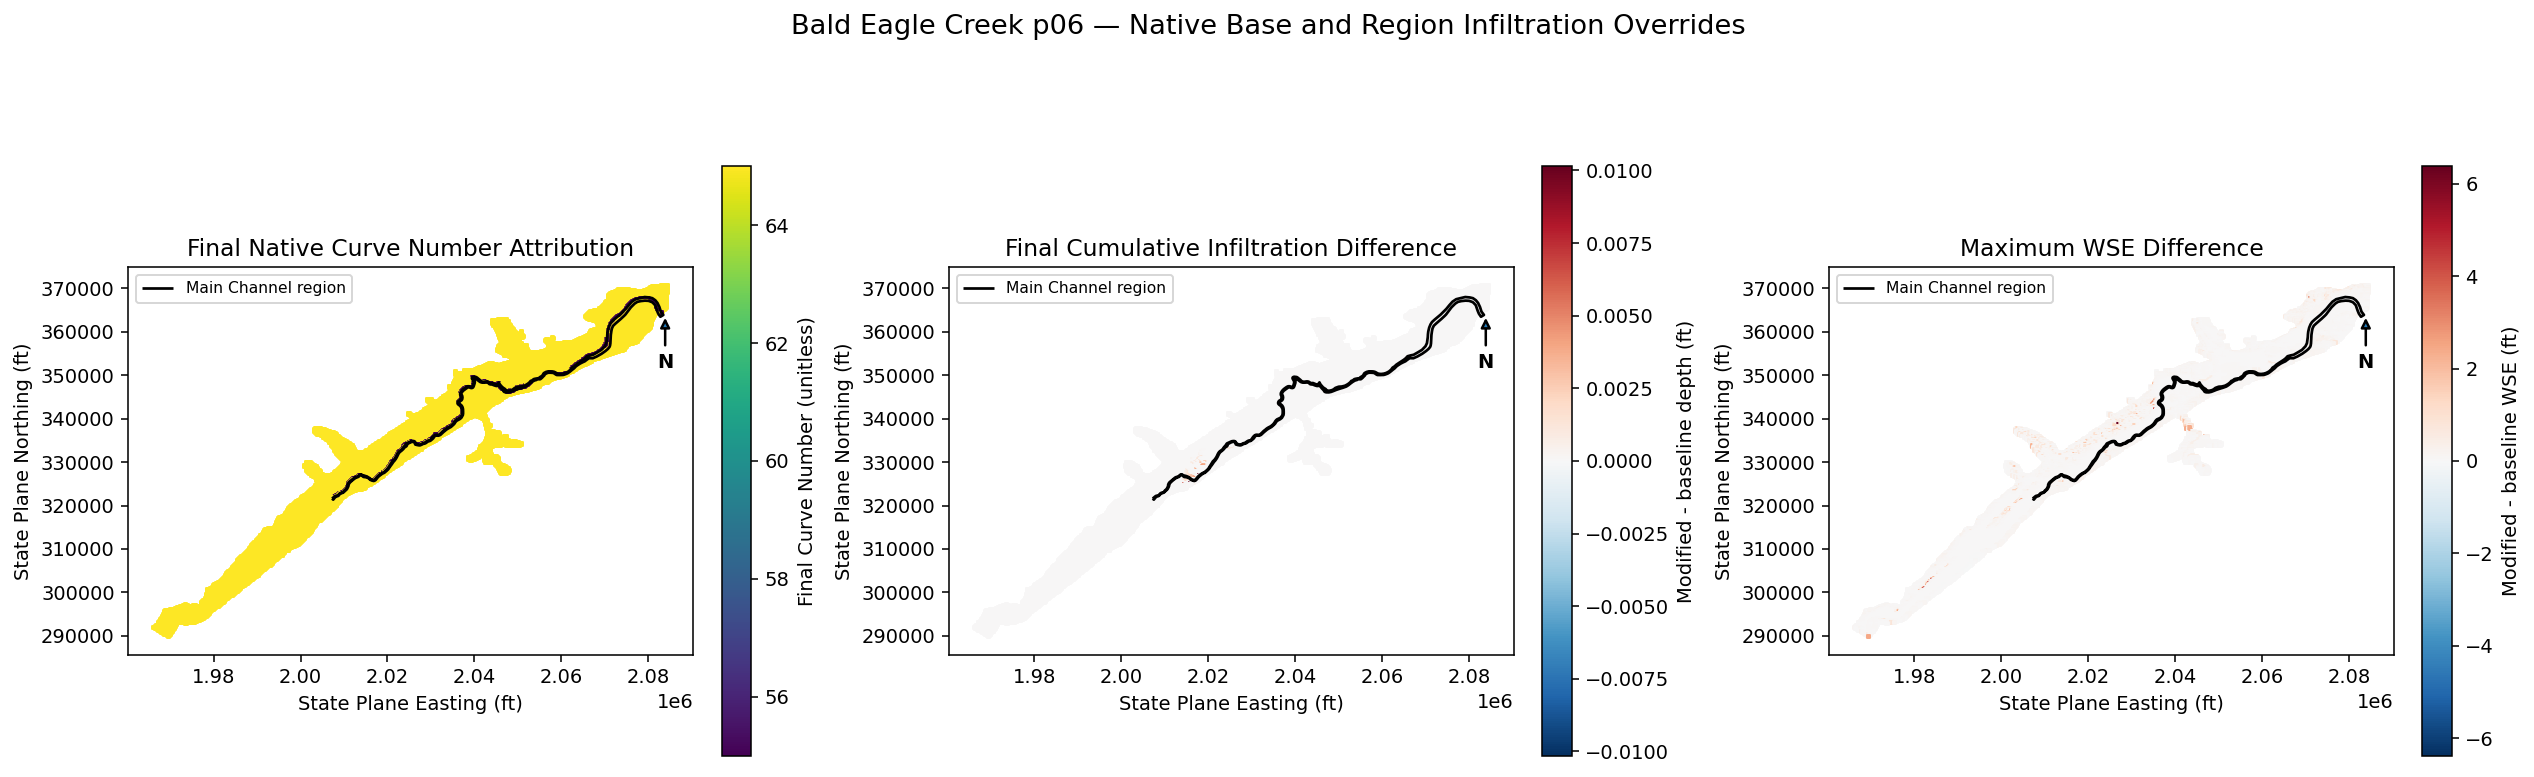

In [10]:
plot_hydraulics = hydraulic_comparison.loc[valid_wse].copy()
curve_number_column = column_names["Curve Number"][1]
infiltration_limit = max(
    float(plot_hydraulics["delta_cumulative_infiltration"].abs().max()),
    0.001,
)
wse_limit = max(
    float(plot_hydraulics["delta_wse"].abs().max()),
    0.001,
)

fig, axes = plt.subplots(
    1, 3, figsize=(18, 6.2), constrained_layout=True
)
array_comparison.plot(
    column=curve_number_column,
    ax=axes[0],
    cmap="viridis",
    marker="s",
    markersize=2.3,
    legend=True,
    vmin=min(BASE_SIGNAL_VALUES["Curve Number"], REGION_SIGNAL_VALUES["Curve Number"]),
    vmax=max(BASE_SIGNAL_VALUES["Curve Number"], REGION_SIGNAL_VALUES["Curve Number"]),
    legend_kwds={"label": "Final Curve Number (unitless)", "shrink": 0.72},
)
axes[0].set_title("Final Native Curve Number Attribution")

for ax, column, title, label, limit in [
    (
        axes[1],
        "delta_cumulative_infiltration",
        "Final Cumulative Infiltration Difference",
        "Modified - baseline depth (ft)",
        infiltration_limit,
    ),
    (
        axes[2],
        "delta_wse",
        "Maximum WSE Difference",
        "Modified - baseline WSE (ft)",
        wse_limit,
    ),
]:
    plot_hydraulics.plot(
        column=column,
        ax=ax,
        cmap="RdBu_r",
        marker="s",
        markersize=2.3,
        legend=True,
        norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit),
        legend_kwds={"label": label, "shrink": 0.72},
    )
    ax.set_title(title)

for ax in axes:
    region_polygons_after.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.4,
        label=f"{REGION_NAME} region",
    )
    ax.set_xlabel("State Plane Easting (ft)")
    ax.set_ylabel("State Plane Northing (ft)")
    ax.set_aspect("equal")
    ax.legend(loc="best")
    ax.annotate(
        "N",
        xy=(0.95, 0.88),
        xytext=(0.95, 0.74),
        xycoords="axes fraction",
        ha="center",
        fontweight="bold",
        arrowprops={"arrowstyle": "-|>", "linewidth": 1.3},
    )
fig.suptitle(
    "Bald Eagle Creek p06 — Native Base and Region Infiltration Overrides",
    fontsize=14,
)
plt.show()


## Conclusions

- Native HEC-RAS created one named geometry infiltration region and the
  complete 136-class schema.
- Geometry-wide Base Overrides and the named region table were edited
  as distinct attribution surfaces; neither API was replaced or
  orphaned.
- Each mutation retained a distinct durable pre-edit backup and passed
  fresh native readback while preserving unrelated state.
- Fully covered cells resolved to the regional signal and fully
  disjoint cells resolved to the geometry-wide base signal.
- The final plan HDF reproduced all recomputed infiltration arrays and
  the full solve produced cumulative infiltration and WSE response.
- No custom HDF authoring, selective dataset deletion, or deprecated
  authoring API was used.
